In [34]:

import pandas as pd

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic shape
print("Rows, Columns:", df.shape)

# Column names and data types
print(df.info())

# First 5 rows
df.head()

Rows, Columns: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Customer Churn Prediction — Week 1

## Problem Statement

Customer churn refers to when a customer stops using a company's product or
service — for example, cancelling a subscription or switching to a competitor.
Churn is one of the most important metrics for subscription-based and service
businesses (telecom, banking, insurance, e-commerce) because acquiring a new
customer is significantly more expensive than retaining an existing one. Even
a small increase in churn can quietly erode revenue over time.

The objective of this project is to build a Machine Learning classification
model that predicts whether a customer is likely to churn, based on their
demographic information, account details, subscription information, service
usage, contract type, tenure, and billing information.

By identifying customers who are at high risk of leaving, the company can
proactively intervene — through targeted offers, improved support, or
personalized retention strategies — before the customer actually cancels,
rather than reacting after the loss has already happened.

**Dataset:** Telco Customer Churn dataset (Kaggle)
**Target variable:** `Churn` (Yes / No)
**Problem type:** Binary Classification


## Data Dictionary

| Feature | Description | Type |
|---|---|---|
| customerID | Unique identifier for each customer | Categorical |
| gender | Customer's gender | Categorical |
| SeniorCitizen | Whether the customer is a senior citizen (1) or not (0) | Categorical |
| Partner | Whether the customer has a partner | Categorical |
| Dependents | Whether the customer has dependents | Categorical |
| tenure | Number of months the customer has stayed with the company | Numerical |
| PhoneService | Whether the customer has phone service | Categorical |
| MultipleLines | Whether the customer has multiple phone lines | Categorical |
| InternetService | Customer's internet service provider type (DSL/Fiber optic/No) | Categorical |
| OnlineSecurity | Whether the customer has online security add-on | Categorical |
| OnlineBackup | Whether the customer has online backup add-on | Categorical |
| DeviceProtection | Whether the customer has device protection add-on | Categorical |
| TechSupport | Whether the customer has tech support add-on | Categorical |
| StreamingTV | Whether the customer has streaming TV service | Categorical |
| StreamingMovies | Whether the customer has streaming movies service | Categorical |
| Contract | Type of contract (Month-to-month/One year/Two year) | Categorical |
| PaperlessBilling | Whether the customer uses paperless billing | Categorical |
| PaymentMethod | Customer's payment method | Categorical |
| MonthlyCharges | Amount charged to the customer monthly | Numerical |
| TotalCharges | Total amount charged to the customer | Numerical |
| Churn | Whether the customer left the company (target variable) | Target |

## Data Quality Report

**Dataset size:** 7,043 rows, 21 columns

**Missing Values:**
No missing values were detected by initial inspection (`df.info()` showed
7,043 non-null entries for every column). However, further investigation of
the `TotalCharges` column revealed 11 rows containing blank space characters
(`" "`) instead of true null values — these were not caught by standard
missing-value checks because Pandas read them as valid (but non-numeric) text.
All 11 affected rows had a `tenure` of 0, meaning these were new customers
with no billing history yet. These values were converted to numeric and
filled with 0.

**Duplicate Records:**
No duplicate rows and no duplicate `customerID` values were found.

**Incorrect Data Types:**
`TotalCharges` was originally stored as an `object` (text) column instead of
numeric, due to the hidden blank space characters described above. It was
converted to `float64` using `pd.to_numeric()`.

**Inconsistent Categorical Values:**
All categorical columns were checked for spelling errors, inconsistent
capitalization, and stray whitespace. No inconsistencies were found —
category values are clean and standardized across the dataset.

**Summary:**
The dataset was largely clean, with one notable issue in `TotalCharges` that
required correction. After cleaning, the dataset is ready for exploratory
data analysis and feature engineering in Week 2.

In [35]:
# Try converting TotalCharges to numeric, and see what breaks
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()

np.int64(11)

In [36]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [37]:
# Convert to numeric for real, turning the blanks into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Since these are new customers with no billing history yet, 0 makes sense
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm it's now a proper number type
df['TotalCharges'].dtype

dtype('float64')

In [38]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df['customerID'].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [39]:
# Check unique values in each categorical (object) column
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].unique())

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [40]:
# Count and percentage of churned vs retained customers
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [41]:
df.to_csv('cleaned_telco_churn.csv', index=False)

In [42]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [43]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [44]:
df['Contract'].value_counts(normalize=True)*100

,proportion
Contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


In [45]:
df['PaymentMethod'].value_counts(normalize=True)*100

,proportion
PaymentMethod,
Electronic check,33.579441
Mailed check,22.887974
Bank transfer (automatic),21.922476
Credit card (automatic),21.610109


In [46]:
df['InternetService'].value_counts(normalize=True)*100

,proportion
InternetService,
Fiber optic,43.958540
DSL,34.374556
No,21.666903


In [47]:
df['OnlineSecurity'].value_counts(normalize=True)*100

,proportion
OnlineSecurity,
No,49.666335
Yes,28.666761
No internet service,21.666903


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

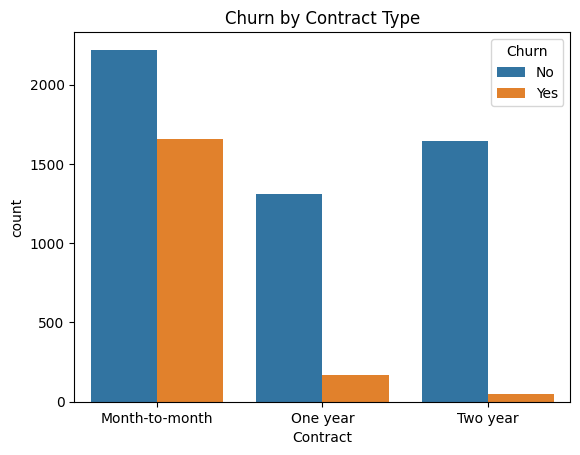

In [49]:
sns.countplot(data=df, x='Contract', hue = 'Churn')
plt.title('Churn by Contract Type')
plt.show()

##Insight
Most customers are on a month-to-month contract(55.02%), while one year contract(20.91%) are the least common


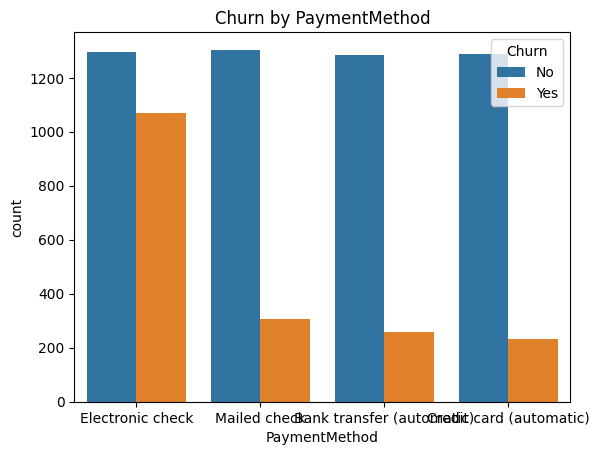

In [50]:
sns.countplot(data=df,x='PaymentMethod', hue='Churn')
plt.title('Churn by PaymentMethod')
plt.show()

##Insight
Most customers pay via electronic check(33.58%) while credit card is the least common method(21.61%)

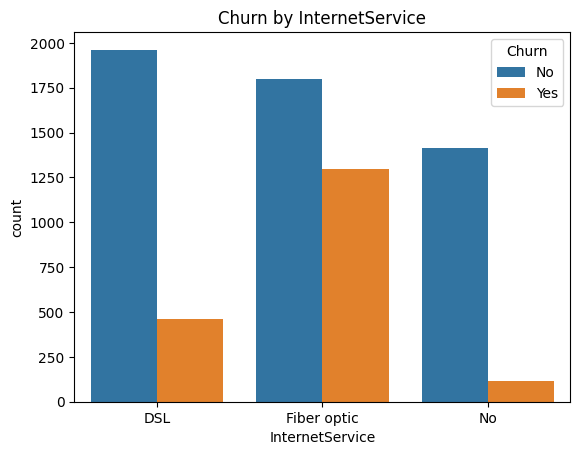

In [51]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by InternetService')
plt.show()

## Insight
Most customers use Fiber optic internet (43.96%), while 21.67% have no internet service at all.

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

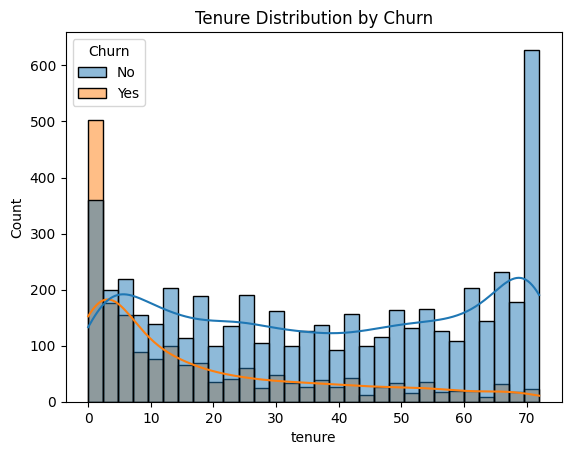

In [53]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

## Insight
Churn is heavily concentrated in month-to-month contracts, while two-year contract customers rarely churn.

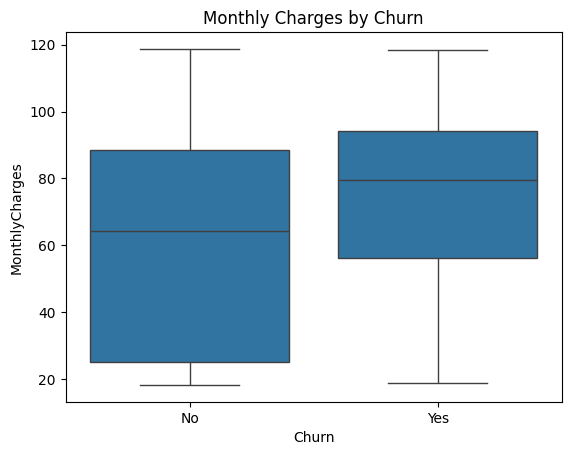

In [54]:
sns.boxplot(data=df, x='Churn',y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

**Insight: Monthly Charges by Churn**

Customers who churned have a higher median MonthlyCharges (~$79) compared to
customers who stayed (~$64). The churned group's charges are also more tightly
clustered in the higher range (roughly $56–$94), while retained customers show
a wider spread, including many on lower-cost plans. This aligns with the
positive correlation found between MonthlyCharges and Churn (+0.19) — customers
paying more per month are somewhat more likely to leave, though the relationship
is weaker than the effect of tenure or contract type.

In [55]:
df['Churn_numeric']=df['Churn'].map({'Yes':1,'No':0})
df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn_numeric']].corr()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_numeric
tenure,1.000000,0.247900,0.826178,0.016567,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.220173,0.193356
TotalCharges,0.826178,0.651174,1.000000,0.103006,-0.198324
SeniorCitizen,0.016567,0.220173,0.103006,1.000000,0.150889
Churn_numeric,-0.352229,0.193356,-0.198324,0.150889,1.000000


In [56]:
for col in ['tenure','MonthlyCharges','TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [57]:
df_encoded = pd.get_dummies(df, columns=['Contract'], drop_first=True)
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric,Contract_One year,Contract_Two year
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Yes,Electronic check,29.85,29.85,No,0,False,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,Mailed check,56.95,1889.50,No,0,True,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Yes,Mailed check,53.85,108.15,Yes,1,False,False
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,No,Bank transfer (automatic),42.30,1840.75,No,0,True,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Yes,Electronic check,70.70,151.65,Yes,1,False,False


In [58]:
multi_cat_cols = ['InternetService', 'PaymentMethod','MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']

df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [59]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({df_encoded[col].unique()[0]: 0, df_encoded[col].unique()[1]: 1})

In [60]:
df_encoded.head()
df_encoded.shape

(7043, 33)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
df_encoded[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [62]:
def tenure_group(months):
    if months <= 12:
        return 'New'
    elif months <= 48:
        return 'Established'
    else:
        return 'Loyal'
df['TenureGroup'] = df['tenure'].apply(tenure_group)
df['TenureGroup'].value_counts()

,count
TenureGroup,
Established,2618
Loyal,2239
New,2186


## Feature Engineering Documentation
Created TenureGroup (New: 0-12 months, Established: 13-48 months, Loyal: 49+ months) to simplify the continuous tenure variable into interpretable categories. New customers show the highest churn rate, consistent with the negative correlation found between tenure and churn.

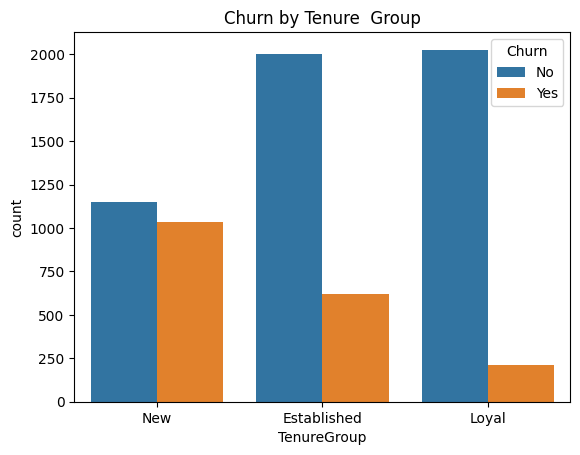

In [63]:
sns.countplot(data=df, x='TenureGroup', hue='Churn')
plt.title('Churn by Tenure  Group')
plt.show()

In [64]:
def charge_group(charges):
    if charges <= 35.50:
        return 'Low'
    elif charges <= 89.85:
        return 'Medium'
    else:
        return 'High'
df['ChargeGroup'] = df['MonthlyCharges'].apply(charge_group)
df['ChargeGroup'].value_counts()

,count
ChargeGroup,
Medium,3523
Low,1762
High,1758


## Feature Engineering Documentation
Created ChargeGroup (Low: ≤$35.50, Medium: 35.50–$89.85, High: >$89.85) based on MonthlyCharges quartiles, to simplify the continuous variable into interpretable pricing tiers.

In [65]:
final_df = df_encoded.drop(columns=['customerID'])
final_df.shape

(7043, 32)

Dropped customerID — no predictive value. Final dataset: 32 columns, including one-hot encoded categorical variables, scaled numeric features, and engineered features TenureGroup and ChargeGroup.

In [66]:
final_df.to_csv('churn_features_week2.csv', index=False)